# 18.3 — Trio tear sheets + Markowitz risk-return planes, two windows

Four sections, in order:

1. **Tear sheet — 2016–2026** for Buy & hold, AI macro factor, SJM de-risk
2. **Markowitz risk-return plane — 2016–2026**
3. **Tear sheet — max timeframe** (same three lines)
4. **Markowitz risk-return plane — max timeframe**

> **The three lines do not share a 2016 start.** Buy & hold runs the full decade, but the
> AI macro-factor and SJM de-risk lines begin **2019-01-02** — their monthly loadings are
> LLM outputs (`openai/gpt-oss-20b` via NVIDIA NIM) and none exist for earlier dates.
> So every table below reports **each line on its own span** *and* on the **common
> window** where all three overlap (2019-01-03 → 2026-01-30). Read the Start/End columns;
> a CAGR over a different window is not comparable to one over this window.

**Max timeframe** is 2009-09-25 → 2026-05-29 (16.67y), bounded by SWDA.L's inception.
Twenty years is not reachable: BIL only lists 2007-05, and the price/macro estate floors at 2010.

Conventions follow `15_2`: elapsed-calendar CAGR, √252 volatility, `ssr_inference` for SSR.
Buy & hold **buys fresh at each window start** — slicing one long line into a shorter window
inherits already-drifted weights and answers a different question.

> **The frontier is hindsight, not an opportunity.** Each plane's efficient frontier is
> estimated on the *same* window it is drawn over, from realized means and covariances. No
> investor could have held it. It is a yardstick for how much of the realized risk-return
> plane the strategies gave up, never a claim that the frontier was attainable. The
> buy-and-hold line is in-sample twice over: its four ETFs were SSR-selected on an
> overlapping window (`scripts/build_static_bh.py`).

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from macro_framework.evaluation import TRADING_DAYS, metric_block
from macro_framework.ssr import ssr_inference

DATA = REPO / "data"
BASKET = ["SWDA.L", "XLK", "IAU", "BIL"]
COLOR = {"Buy & hold": "#2f6db3", "AI macro factor": "#e8710a", "SJM de-risk": "#8656c9"}


def active(v: pd.Series) -> pd.Series:
    """Trim the flat pre-start stub: last flat day before the first move, onward."""
    moving = v[v.ne(v.iloc[0])]
    if moving.empty:
        return v
    prior = v.index[v.index < moving.index.min()]
    return v.loc[(prior.max() if len(prior) else moving.index.min()):]


def load(stem: str) -> pd.Series:
    return active(pd.read_parquet(DATA / f"{stem}.parquet")["value"])


# Buy & hold is rebuilt per window (fresh buy); the AI lines are single persisted streams.
BH_10Y = load("static_bh_equity_2016_2026")       # bought 2016-01-31
BH_MAX = load("static_bh_equity_2009_2026")       # bought 2009-09-25
FACTOR = load("factor_equity_ext2026")
SJM    = load("sjm_crowding_derisk_v2_equity_ext2026")

px_long = pd.read_parquet(DATA / "basket_close_2009_2026.parquet")[BASKET]

W_10Y = (BH_10Y.index.min(), BH_10Y.index.max())
W_MAX = (BH_MAX.index.min(), BH_MAX.index.max())
W_COMMON = (max(BH_10Y.index.min(), FACTOR.index.min(), SJM.index.min()),
            min(BH_10Y.index.max(), FACTOR.index.max(), SJM.index.max()))

for name, (a, b) in [("2016-2026", W_10Y), ("max", W_MAX), ("common (all three)", W_COMMON)]:
    print(f"{name:20s} {a:%Y-%m-%d} -> {b:%Y-%m-%d}  ({(b - a).days / 365.25:5.2f}y)")
print(f"\nprice panel: {px_long.index.min():%Y-%m-%d} -> {px_long.index.max():%Y-%m-%d}")

2016-2026            2016-02-01 -> 2026-01-30  (10.00y)
max                  2009-09-25 -> 2026-05-29  (16.67y)
common (all three)   2019-01-02 -> 2026-01-30  ( 7.08y)

price panel: 2009-09-25 -> 2026-05-29


In [2]:
def tear_row(v: pd.Series, label: str, window: str) -> dict:
    """One tear-sheet row. SSR is the effect size; the verdict sentence carries the
    inference. The standalone MBB p is deliberately NOT a tear-sheet column."""
    m = metric_block(v)
    inf = ssr_inference(m["returns"])
    return {
        "Line": label, "Window": window,
        "Start": v.index.min().date(), "End": v.index.max().date(),
        "Days": len(m["returns"]),
        "Total Return": m["total_return"], "CAGR": m["cagr"],
        "Ann. Volatility": m["ann_vol"], "Sharpe": m["sharpe"], "Sortino": m["sortino"],
        "Max Drawdown": m["maxdd"], "Calmar": m["calmar"],
        "SSR": inf.result.ssr, "SSR verdict": inf.verdict(),
    }


PCT = {"Total Return", "CAGR", "Ann. Volatility", "Max Drawdown"}
RATIO = {"Sharpe", "Sortino", "Calmar", "SSR"}


def render(rows: list[dict], *, verdicts: bool = True) -> pd.DataFrame:
    df = pd.DataFrame(rows).set_index(["Line", "Window"])
    out = df.drop(columns=["SSR verdict"]).copy()
    for c in out.columns:
        if c in PCT:
            out[c] = out[c].map("{:.2%}".format)
        elif c in RATIO:
            out[c] = out[c].map("{:.3f}".format)
    if verdicts:
        for (line, win), v in df["SSR verdict"].items():
            print(f"  {line} [{win}]: {v}")
    return out

## 1. Tear sheet — 2016–2026

Buy & hold spans the whole decade; the two AI lines cannot. Both spans are shown: each
line on its **own** maximum span inside 2016–2026, then all three re-cut to the
**common window** so the columns are directly comparable.

In [3]:
rows_own_10y = [
    tear_row(BH_10Y, "Buy & hold", "own span"),
    tear_row(FACTOR.loc[:W_10Y[1]], "AI macro factor", "own span"),
    tear_row(SJM.loc[:W_10Y[1]], "SJM de-risk", "own span"),
]
rows_common = [
    tear_row(BH_10Y.loc[W_COMMON[0]:W_COMMON[1]], "Buy & hold", "common"),
    tear_row(FACTOR.loc[W_COMMON[0]:W_COMMON[1]], "AI macro factor", "common"),
    tear_row(SJM.loc[W_COMMON[0]:W_COMMON[1]], "SJM de-risk", "common"),
]
print("SSR verdicts (2016-2026 era):")
sheet_10y = render(rows_own_10y + rows_common)
TEAR = DATA / "tear_sheet"
pd.DataFrame(rows_own_10y + rows_common).to_csv(TEAR / "tear_sheet_trio_2016_2026.csv", index=False)
pd.DataFrame(rows_own_10y + rows_common).to_csv(
    TEAR / "tear_sheet_trio_2016_2026_de.csv", sep=";", decimal=",", index=False)
sheet_10y

SSR verdicts (2016-2026 era):
  Buy & hold [own span]: SSR=0.15: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  AI macro factor [own span]: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  SJM de-risk [own span]: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  Buy & hold [common]: SSR=0.14: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  AI macro factor [common]: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  SJM de-risk [common]: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim


,,Start,End,Days,Total Return,CAGR,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,SSR
Line,Window,,,,,,,,,,,
Buy & hold,own span,2016-02-01,2026-01-30,2468,320.07%,15.44%,12.93%,1.198,1.728,-19.63%,0.787,0.147
AI macro factor,own span,2019-01-02,2026-01-30,1745,148.79%,13.74%,9.21%,1.476,2.159,-12.08%,1.138,0.130
SJM de-risk,own span,2019-01-02,2026-01-30,1745,137.21%,12.98%,8.13%,1.575,2.287,-8.38%,1.548,0.134
Buy & hold,common,2019-01-02,2026-01-30,1745,224.33%,18.09%,14.65%,1.234,1.782,-19.63%,0.921,0.143
AI macro factor,common,2019-01-02,2026-01-30,1745,148.79%,13.74%,9.21%,1.476,2.159,-12.08%,1.138,0.130
SJM de-risk,common,2019-01-02,2026-01-30,1745,137.21%,12.98%,8.13%,1.575,2.287,-8.38%,1.548,0.134


## 2. Markowitz risk-return plane — 2016–2026

Mean-variance geometry on the same four ETFs the strategies trade. **x = annualized
volatility, y = annualized arithmetic mean return** — the plane Markowitz optimizes over,
which is why the y-axis is the arithmetic mean and not CAGR (the two differ by roughly
σ²/2). The curve is the long-only efficient frontier: minimum variance at each attainable
return, no shorting, no leverage, fully invested.

**Left** is the 2016–2026 window, where only buy & hold exists. **Right** is the common
window, where all three do — with its own frontier, because the opportunity set is not
the same set on a different decade.

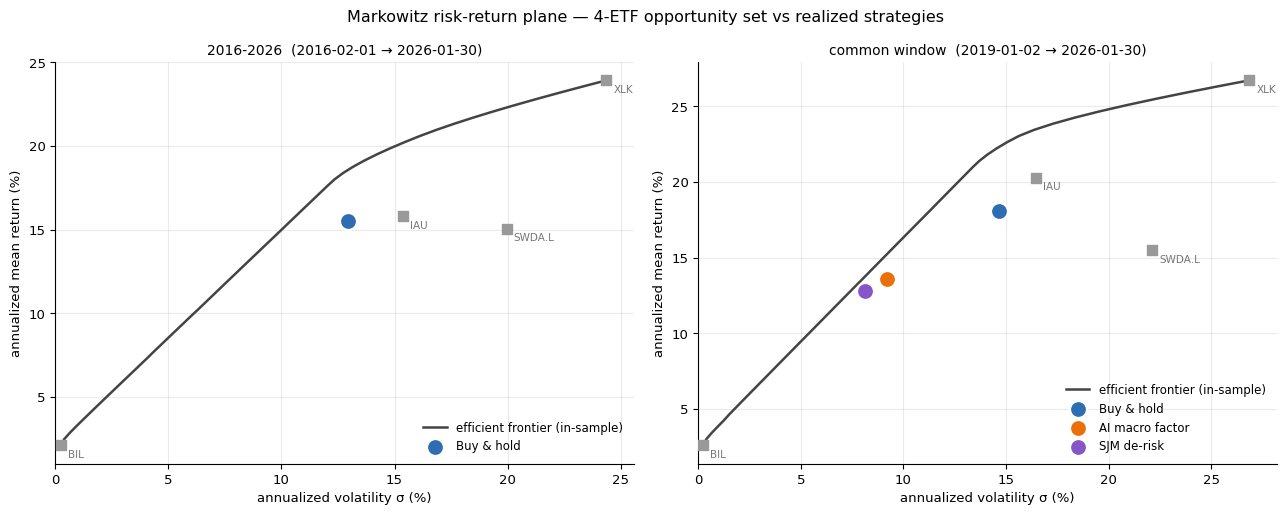

In [4]:
def frontier(rets: pd.DataFrame, n_points: int = 60) -> pd.DataFrame:
    """Long-only mean-variance frontier: min w'Σw s.t. w'μ = target, Σw = 1, w ≥ 0."""
    mu = rets.mean().to_numpy() * TRADING_DAYS
    cov = rets.cov().to_numpy() * TRADING_DAYS
    k = len(mu)
    bounds = [(0.0, 1.0)] * k
    w0 = np.full(k, 1 / k)
    pts = []
    for target in np.linspace(mu.min(), mu.max(), n_points):
        cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},
                {"type": "eq", "fun": lambda w, t=target: w @ mu - t})
        r = minimize(lambda w: w @ cov @ w, w0, method="SLSQP",
                     bounds=bounds, constraints=cons)
        if r.success:
            pts.append({"vol": float(np.sqrt(r.fun)), "ret": float(target)})
    return pd.DataFrame(pts).sort_values("vol").reset_index(drop=True)


def plane(ax, rets: pd.DataFrame, lines: dict[str, pd.Series], title: str) -> None:
    f = frontier(rets)
    ax.plot(f["vol"] * 100, f["ret"] * 100, color="#444444", lw=1.8, zorder=2,
            label="efficient frontier (in-sample)")
    for s in rets.columns:  # the four assets themselves
        ax.scatter(rets[s].std(ddof=1) * np.sqrt(TRADING_DAYS) * 100,
                   rets[s].mean() * TRADING_DAYS * 100, s=42, color="#999999",
                   marker="s", zorder=3)
        ax.annotate(s, (rets[s].std(ddof=1) * np.sqrt(TRADING_DAYS) * 100,
                        rets[s].mean() * TRADING_DAYS * 100),
                    xytext=(5, -9), textcoords="offset points", fontsize=7.5, color="#777777")
    for lbl, v in lines.items():
        r = v.pct_change().dropna()
        x, y = r.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100, r.mean() * TRADING_DAYS * 100
        ax.scatter(x, y, s=150, color=COLOR[lbl], edgecolor="white", linewidth=1.6,
                   zorder=4, label=lbl)
    ax.set_xlabel("annualized volatility σ (%)")
    ax.set_ylabel("annualized mean return (%)")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25, zorder=0)
    ax.set_xlim(left=0)


plt.rcParams.update({"font.size": 9.5, "axes.spines.top": False, "axes.spines.right": False})
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2))

ret_10y = px_long.loc[W_10Y[0]:W_10Y[1]].pct_change().dropna()
plane(axL, ret_10y, {"Buy & hold": BH_10Y},
      f"2016-2026  ({W_10Y[0]:%Y-%m-%d} → {W_10Y[1]:%Y-%m-%d})")

ret_com = px_long.loc[W_COMMON[0]:W_COMMON[1]].pct_change().dropna()
plane(axR, ret_com, {"Buy & hold": BH_10Y.loc[W_COMMON[0]:W_COMMON[1]],
                     "AI macro factor": FACTOR.loc[W_COMMON[0]:W_COMMON[1]],
                     "SJM de-risk": SJM.loc[W_COMMON[0]:W_COMMON[1]]},
      f"common window  ({W_COMMON[0]:%Y-%m-%d} → {W_COMMON[1]:%Y-%m-%d})")
axR.legend(frameon=False, fontsize=8.5, loc="lower right")
axL.legend(frameon=False, fontsize=8.5, loc="lower right")
fig.suptitle("Markowitz risk-return plane — 4-ETF opportunity set vs realized strategies",
             fontsize=11.5)
fig.tight_layout()
fig.savefig(DATA / "nb18_3_markowitz_plane_2016_2026.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Tear sheet — max timeframe

Buy & hold bought at **2009-09-25** and held to 2026-05-29 (16.67y). The two AI lines are
unchanged from section 1 — they cannot reach back, so their "max" *is* 2019 onward, and
here they run to their own end (2026-06-30) rather than being clipped to January.

In [5]:
rows_max = [
    tear_row(BH_MAX, "Buy & hold", "max own"),
    tear_row(FACTOR, "AI macro factor", "max own"),
    tear_row(SJM, "SJM de-risk", "max own"),
]
print("SSR verdicts (max timeframe):")
sheet_max = render(rows_max)
pd.DataFrame(rows_max).to_csv(TEAR / "tear_sheet_trio_max.csv", index=False)
pd.DataFrame(rows_max).to_csv(TEAR / "tear_sheet_trio_max_de.csv",
                              sep=";", decimal=",", index=False)
sheet_max

SSR verdicts (max timeframe):
  Buy & hold [max own]: SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  AI macro factor [max own]: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  SJM de-risk [max own]: SSR=0.14: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim


,,Start,End,Days,Total Return,CAGR,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,SSR
Line,Window,,,,,,,,,,,
Buy & hold,max own,2009-09-25,2026-05-29,4115,726.43%,13.50%,14.00%,0.994,1.414,-24.24%,0.557,0.120
AI macro factor,max own,2019-01-02,2026-06-30,1845,165.54%,13.93%,9.67%,1.429,2.072,-12.08%,1.153,0.134
SJM de-risk,max own,2019-01-02,2026-06-30,1845,148.07%,12.89%,8.57%,1.492,2.139,-11.24%,1.147,0.138


## 4. Markowitz risk-return plane — max timeframe

Same geometry, opportunity set estimated over the full 16.67 years. The frontier shifts:
a longer window includes 2011–2015, when the basket's equity legs returned far less than
they did after 2019, so the whole attainable plane sits lower and the strategies' realized
points move with it.

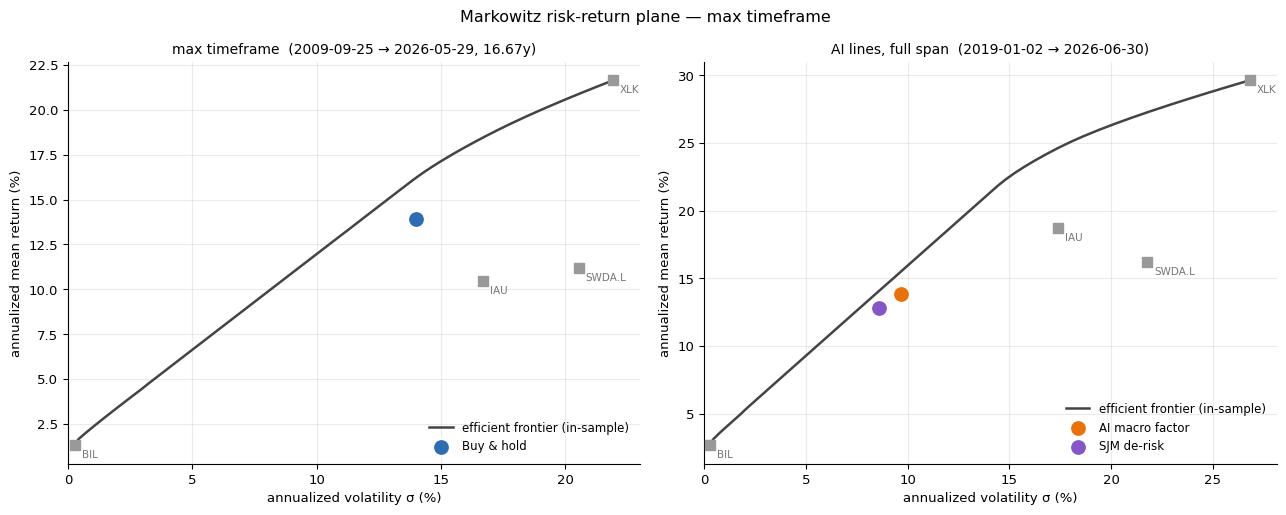

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2))

ret_max = px_long.loc[W_MAX[0]:W_MAX[1]].pct_change().dropna()
plane(axL, ret_max, {"Buy & hold": BH_MAX},
      f"max timeframe  ({W_MAX[0]:%Y-%m-%d} → {W_MAX[1]:%Y-%m-%d}, 16.67y)")

# the AI lines on their own full span, against that span's frontier
W_AI = (FACTOR.index.min(), FACTOR.index.max())
ret_ai = px_long.loc[W_AI[0]:W_AI[1]].pct_change().dropna()
plane(axR, ret_ai, {"AI macro factor": FACTOR, "SJM de-risk": SJM},
      f"AI lines, full span  ({W_AI[0]:%Y-%m-%d} → {W_AI[1]:%Y-%m-%d})")
axL.legend(frameon=False, fontsize=8.5, loc="lower right")
axR.legend(frameon=False, fontsize=8.5, loc="lower right")
fig.suptitle("Markowitz risk-return plane — max timeframe", fontsize=11.5)
fig.tight_layout()
fig.savefig(DATA / "nb18_3_markowitz_plane_max.png", dpi=300, bbox_inches="tight")
plt.show()

## Reading guide

- **Distance below the frontier is the honest read.** All three strategies sit inside the
  in-sample frontier on every window. That gap is not a defect — the frontier is fitted on
  the realized moments of the window it spans and was never investable. It bounds how much
  of the realized plane was left on the table by *any* rule, including hindsight ones.
- **The two AI lines sit left of buy & hold on every plane**: less volatility, less
  arithmetic return. Whether that trade is good is a risk-adjusted question, and the answer
  depends on the window — see the Sharpe/Calmar columns in §1 and §3, and note they are
  computed on *different* spans.
- **The max-timeframe frontier sits lower** than the 2016–2026 one. Extending back to 2009
  adds years in which the basket simply returned less, which is the same start-date
  dependence `18_2` quantifies for buy & hold alone.
- SSR appears as an effect size with its verdict sentence. It is **not** rankable and the
  standalone MBB p is deliberately not a tear-sheet column.

Figures: `data/nb18_3_markowitz_plane_{2016_2026,max}.png` at 300 dpi.
Tables: `data/tear_sheet/tear_sheet_trio_{2016_2026,max}[_de].csv`.

In [7]:
# Self-check: the common-window rows must reproduce the published trio tear sheet.
pub = pd.read_csv(DATA / "tear_sheet" / "tear_sheet_trio_ext2026.csv").set_index("Label")
PUB_NAME = {"Buy & hold": "Static B&H 16-26", "AI macro factor": "Factor ext26",
            "SJM de-risk": "SJM×crowding de-risk v2 ext26"}
TOL = 5e-9  # == %.8f's half-ulp; bound is inclusive by design
checked = 0
for row in rows_common:
    col = pub.loc[PUB_NAME[row["Line"]]]
    for mine, theirs in [("CAGR", "CAGR"), ("Ann. Volatility", "Ann. Volatility"),
                         ("Sharpe", "Sharpe"), ("Max Drawdown", "Max Drawdown"),
                         ("Calmar", "Calmar"), ("Total Return", "Total Return")]:
        assert abs(row[mine] - float(col[theirs])) <= TOL, (row["Line"], mine, row[mine], col[theirs])
        checked += 1
print(f"self-check vs tear_sheet_trio_ext2026.csv: PASS ({checked} pins)")

# The AI lines must genuinely not exist before 2019 — the premise of this notebook.
for lbl, v in [("AI macro factor", FACTOR), ("SJM de-risk", SJM)]:
    assert v.index.min() >= pd.Timestamp("2019-01-01"), (lbl, v.index.min())
print(f"AI lines start: factor {FACTOR.index.min():%Y-%m-%d}, sjm {SJM.index.min():%Y-%m-%d} — "
      "no pre-2019 data, as stated")

self-check vs tear_sheet_trio_ext2026.csv: PASS (18 pins)
AI lines start: factor 2019-01-02, sjm 2019-01-02 — no pre-2019 data, as stated
